# Assignment 1

This assignment covers material from Weeks 1–4. Think of it as a spot-check: five exercises that test important analytical and visualization skills from the first part of the course.

## Formalia:

<mark>Please read the **[assignment overview page](https://github.com/suneman/socialdata2026/wiki/Assignments)** carefully before proceeding.</mark> This page contains information about formatting (including formats etc.), group sizes, and many other aspects of handing in the assignment. 

***If you fail to follow these simple instructions, it will negatively impact your grade!***

**Due date and time**: The assignment is due on Monday March 2nd, 2026 at 23:55. Hand in your files via DTU Learn. 

## Important Notes:
**All exercises use your combined SF crime dataset** (2003–present) that you built during Week 2, along with your Personal Focus Crimes. Make sure you have those ready before you start.
* **Hint**: The number of focus crimes are up to you, but choosing very few focus-crimes (1-5, let's say) feels like taking the easy way out to me, so to get top marks, you'll need 8 or more focus crimes (but it's not that more are better, 16 isn't necessarily better than 8).

Each assignment draws directly on the weekly exercises - you should be able to pull your work directly from there.

<div class="alert alert-block alert-info">
The same LLM guidance applies here as during the weekly exercises: use your LLM freely for coding, pandas syntax, and plot formatting. Do not use it for interpretation, reflection, or anything that asks for your own thinking. 
<br>  <br>
If you use and LLM to cheat, you are missing out on your education ... it will mean that you're not getting all you can out of this class ... and, more importantly, that you are literally wasting this crucial time of your DTU-journey, designed to make you smarter and ready for the world.
</div>

---
## Assignment 1.1: Temporal Overview

Let's start by getting the big picture of how crime has changed over the full 20+ year period covered by your combined dataset.

*Draws from*: Week 1, Exercises 4.1 and 4.2 — applied here to the full merged dataset (2003–present) rather than just 2018–present.

### 1.1A
> * Using your combined dataset (2003–present), plot the total number of incidents **per year** for each of your Personal Focus Crimes. Display at least the years 2003–2025. 
> * Make sure your plot follows good visualization practices: labeled axes, a legend, a descriptive title.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("SFPD_Combined_Data.csv") #dataset load
df.head()

,Incident Category,Police District,Incident Date,Incident Time,Latitude,Longitude
0,recovered vehicle,Out of SF,2025-08-26,23:17,NaN,NaN
1,assault,Park,2025-08-27,00:37,37.780415,-122.449013
2,fraud,Park,2025-07-17,15:00,37.775177,-122.451355
3,larceny theft,Northern,2025-08-23,21:30,37.774551,-122.422501
4,lost property,Park,2025-08-15,12:00,37.769661,-122.449646


In [3]:
focus_crimes = ["assault", "larceny theft", "motor vehicle theft", "burglary", "robbery", "gambling","sex offense","weapons offense", "fraud", "arson"]
focus_crimes_df = df[df['Incident Category'].isin(focus_crimes)].copy() #focus crimes dataframe
focus_crimes_df.head()

,Incident Category,Police District,Incident Date,Incident Time,Latitude,Longitude
1,assault,Park,2025-08-27,00:37,37.780415,-122.449013
2,fraud,Park,2025-07-17,15:00,37.775177,-122.451355
3,larceny theft,Northern,2025-08-23,21:30,37.774551,-122.422501
5,motor vehicle theft,Park,2025-08-15,21:45,37.771572,-122.442184
6,larceny theft,Southern,2025-08-14,21:00,NaN,NaN


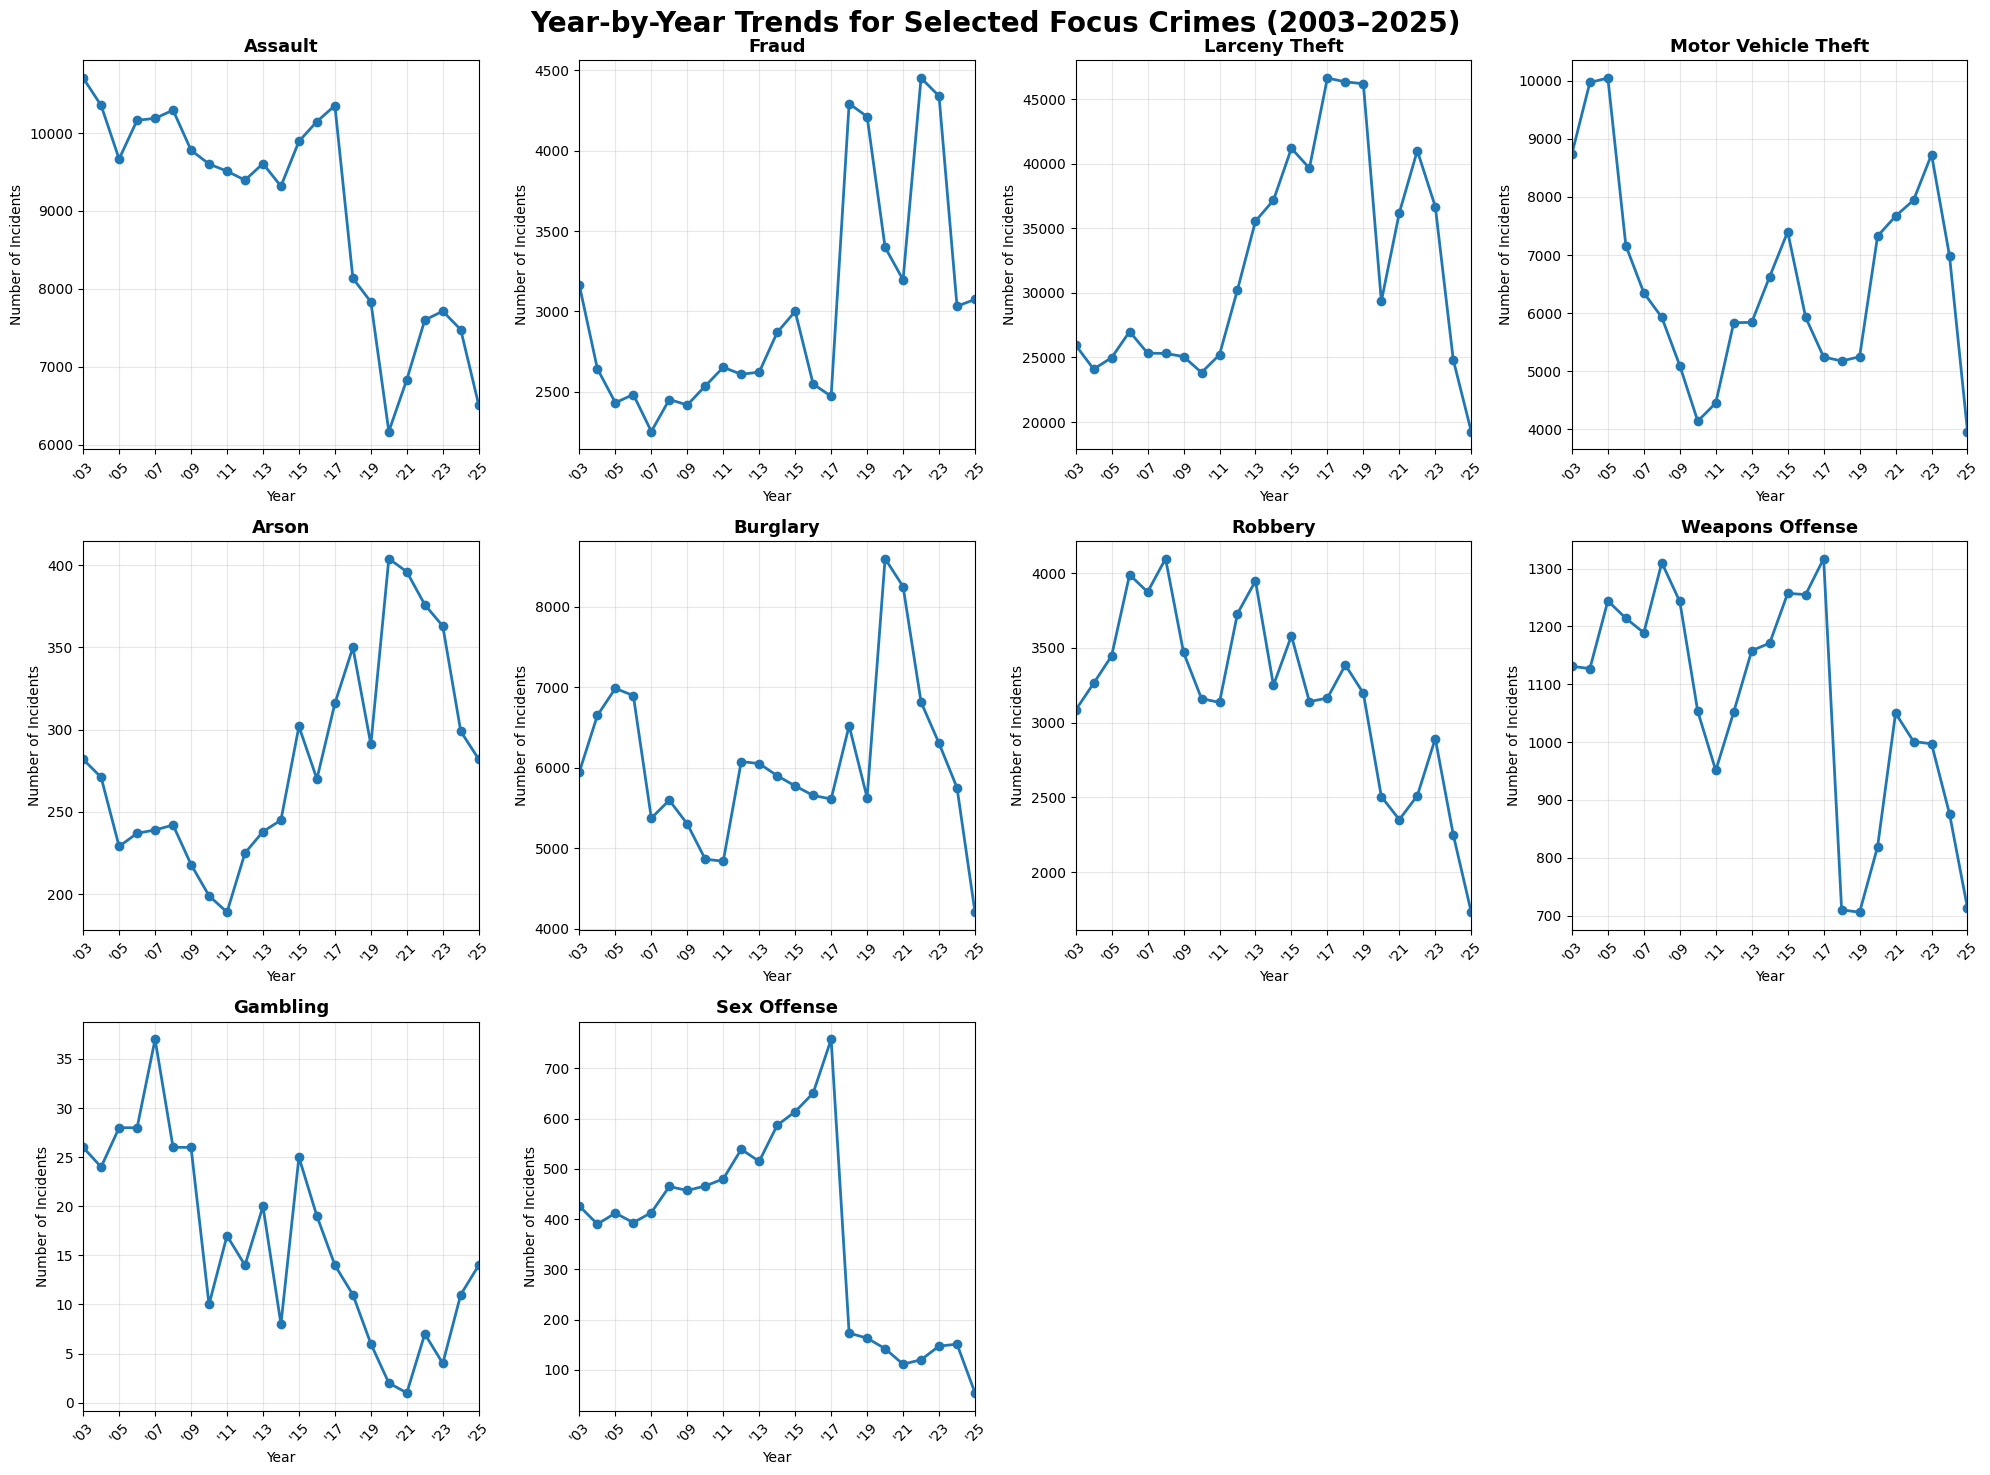

In [4]:
import math
import matplotlib.pyplot as plt

# Convert Incident Date to datetime once
focus_crimes_df["Incident Date"] = pd.to_datetime(
    focus_crimes_df["Incident Date"], errors="coerce"
)

unique_focus_crimes = focus_crimes_df["Incident Category"].unique()
n_crimes = len(unique_focus_crimes)

n_cols = 4
n_rows = math.ceil(n_crimes / n_cols)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes_list = axs.flatten()

for i, crime in enumerate(unique_focus_crimes):
    ax = axes_list[i]

    crime_df = focus_crimes_df[
        focus_crimes_df["Incident Category"] == crime
    ]

    # Count per year
    yearly_counts = (
        crime_df["Incident Date"]
        .dt.year
        .value_counts()
        .sort_index()
    )

    # Ensure full 2003–2025 range appears (even if 0)
    all_years = range(2003, 2026)
    yearly_counts = yearly_counts.reindex(all_years, fill_value=0)

    ax.plot(
        yearly_counts.index,
        yearly_counts.values,
        marker='o',
        linewidth=2
    )

    ax.set_title(crime.title(), fontsize=13, fontweight='bold')
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of Incidents")

    # Custom formatted x-axis ('03, '05, ...) ----
    display_years = list(all_years)[::2]  # every 2 years
    ax.set_xticks(display_years)
    ax.set_xticklabels(
        [f"'{str(year)[-2:]}" for year in display_years],
        rotation=45
    )

    ax.set_xlim(2003, 2025)
    ax.grid(alpha=0.3)

# Remove extra empty plots
for j in range(i + 1, len(axes_list)):
    fig.delaxes(axes_list[j])

plt.suptitle(
    "Year-by-Year Trends for Selected Focus Crimes (2003–2025)",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### 1.1B
> * Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.

From the plot, we observe that violent crimes such as Assault and Robbery follow a relatively stable long-term pattern. Their year-to-year fluctuations are smaller compared to other categories, particularly property crimes. This relative stability may be explained by the fact that violent crimes are more closely associated with structural social factors, such as demographic composition, socioeconomic conditions, and long-term behavioral patterns, which tend to evolve gradually rather than abruptly.

Another important observation concerns the pandemic period around 2020. Several crime categories show a noticeable decline during this time. A plausible explanation is the implementation of stay-at-home measures in San Francisco starting on March 17, 2020, which reduced mobility and social interaction (San Francisco Department of Public Health, 2020; Google COVID-19 Community Mobility Reports, 2020). This mechanism is also consistent with early evidence on COVID-related crime pattern changes (Ashby, 2020).

Additionally, we observe a sharp decrease in some categories, such as Sex Offense, after 2017. This sudden change may not necessarily reflect a real drop in incidents, but rather a modification in reporting practices, classification standards, or dataset structure. Therefore, such abrupt shifts should be interpreted cautiously, as they may be influenced by changes in data recording rather than actual crime dynamics.


---
## Assignment 1.2: Crime Profiles by Police District

Different parts of the city have very different crime patterns. Here we quantify that using conditional probabilities.

*Draws from*: Week 3, Exercises 2.1 and 2.2.






### 1.2A

> * For each police district in your dataset, compute the **conditional crime profile**: for each of your Personal Focus Crimes, calculate
>
>   $$r(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$
>
>   A value above 1 means that crime type is *over-represented* in that district relative to the city-wide average; below 1 means it is *under-represented*.

In [5]:
focus_crimes_df

,Incident Category,Police District,Incident Date,Incident Time,Latitude,Longitude
1,assault,Park,2025-08-27,00:37,37.780415,-122.449013
2,fraud,Park,2025-07-17,15:00,37.775177,-122.451355
3,larceny theft,Northern,2025-08-23,21:30,37.774551,-122.422501
5,motor vehicle theft,Park,2025-08-15,21:45,37.771572,-122.442184
6,larceny theft,Southern,2025-08-14,21:00,NaN,NaN
...,...,...,...,...,...,...
2823492,larceny theft,SOUTHERN,2008-01-13,00:01,37.785207,-122.406691
2823494,larceny theft,NORTHERN,2013-01-27,10:00,37.784677,-122.432118
2823496,larceny theft,SOUTHERN,2004-07-12,20:00,37.784189,-122.407634
2823500,robbery,INGLESIDE,2012-07-02,18:00,37.713168,-122.409860


In [6]:
#calculate p(crime)
p_crime = focus_crimes_df["Incident Category"].value_counts(normalize=True)

#compute probability of each crime per district
p_crime_per_district = (focus_crimes_df.groupby("Police District")["Incident Category"]).value_counts(normalize=True).rename("p").reset_index()

#compute ratio
P_crime_df = p_crime.rename("p_city").reset_index().rename(columns={"index": "Incident Category"})
ratio_df = p_crime_per_district.merge(P_crime_df, on="Incident Category", how="left")
ratio_df["ratio"] = ratio_df["p"] / ratio_df["p_city"]
print(ratio_df)


    Police District    Incident Category         p    p_city     ratio
0           BAYVIEW        larceny theft  0.331882  0.519622  0.638699
1           BAYVIEW              assault  0.220907  0.146271  1.510256
2           BAYVIEW  motor vehicle theft  0.167162  0.107061  1.561370
3           BAYVIEW             burglary  0.117165  0.098426  1.190394
4           BAYVIEW              robbery  0.074504  0.051583  1.444337
..              ...                  ...       ...       ...       ...
202      Tenderloin                fraud  0.055376  0.048802  1.134700
203      Tenderloin      weapons offense  0.028075  0.017321  1.620850
204      Tenderloin                arson  0.006818  0.004566  1.493337
205      Tenderloin          sex offense  0.003638  0.006078  0.598548
206      Tenderloin             gambling  0.000516  0.000270  1.912632

[207 rows x 5 columns]


### 1.2B
> * Visualize these ratios in a way that makes it easy to compare across both districts and crime types. (Simple barcharts are fine, but you may also use ideas from more complex visualization techniques, for example, a heatmap could work well here, but you're free to choose another format if you can justify it.)

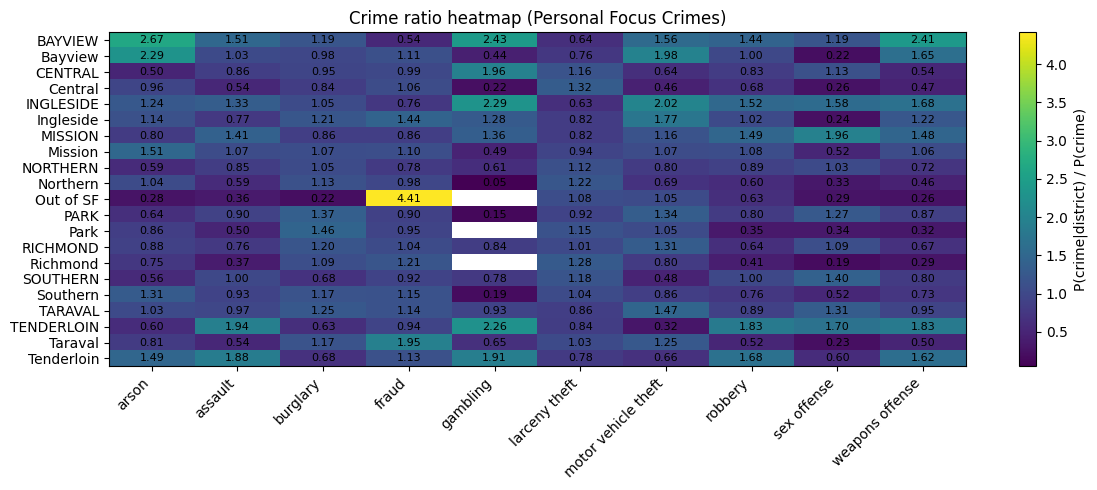

In [7]:
import numpy as np

heat = ratio_df.pivot(
    index="Police District",
    columns="Incident Category",
    values="ratio"
)

plt.figure(figsize=(12, 5))
img = plt.imshow(heat, aspect="auto")
plt.colorbar(img, label="P(crime|district) / P(crime)")

# --- annotate each cell with the ratio value ---
for i in range(heat.shape[0]):          # rows (districts)
    for j in range(heat.shape[1]):      # cols (crime types)
        val = heat.iat[i, j]            # fast cell access
        if pd.notna(val):               # skip missing cells
            plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

plt.xticks(range(len(heat.columns)), heat.columns, rotation=45, ha="right")
plt.yticks(range(len(heat.index)), heat.index)
plt.title("Crime ratio heatmap (Personal Focus Crimes)")
plt.tight_layout()
plt.show()


### 1.2C

> * Pick **one district** whose profile stands out to you. Describe the pattern and offer an explanation for why that district looks the way it does. Are there geographic, demographic, or other factors that might explain it?

The district that stands out to me is Bayview. Bayview shows high ratios in arson, assault, gambling, motor vehicle theft, and weapons offense (all above 1 in this analysis). A possible contextual explanation is that Bayview-Hunters Point has historically differed from the city average in key socioeconomic and demographic indicators (San Francisco Planning Department, 2017). Planning and housing reports also describe long-term disinvestment pressures in parts of the Bayview/Third Street corridor (San Francisco MOHCD, 2021), which may help explain district-level differences in crime composition.

One possible explanation is localized territorial conflict, but this should be treated as a hypothesis unless supported by specific district-level evidence for the same time period.


---
## Assignment 1.3: Visualizing Distributions

This exercise asks you to recreate several classic plot types from DAOST Chapter 2 using your own crime data — putting visualization theory into practice.

*Draws from*: Week 3, Exercises 5.2 and 5.3.


### 1.3A

> **Part A — Jitter plot**
> * Pick one of your Personal Focus Crimes and a suitable time interval (somewhere between a month and 6 months, depending on how common the crime is). Create a jitter plot of the incident times during a single hour (e.g. 13:00–14:00): let time run along the $x$-axis and add vertical jitter.
> * What does the jitter plot reveal about how times are recorded in the dataset? Are incidents clustered at certain minutes (on the hour, half hour, etc.)? What does this tell you about the precision of the data?

In [8]:
# Ensure datetime types (safe even if already datetime64[ns])
df["Incident Date"] = pd.to_datetime(df["Incident Date"], errors="coerce")
df["Incident Time"] = pd.to_datetime(df["Incident Time"], errors="coerce")

# Build a real incident timestamp
df["Incident Datetime"] = df["Incident Date"] + (
    pd.to_timedelta(df["Incident Time"].dt.hour, unit="h") +
    pd.to_timedelta(df["Incident Time"].dt.minute, unit="m")
)

# Extract hour/minute for filtering + plotting
df["hour"] = df["Incident Datetime"].dt.hour
df["minute"] = df["Incident Datetime"].dt.minute

df[["Incident Date", "Incident Time", "Incident Datetime", "hour", "minute"]].head()

/var/folders/vf/5fp3km_j7cgbcrs85nqynb000000gn/T/ipykernel_59437/1151293741.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Incident Time"] = pd.to_datetime(df["Incident Time"], errors="coerce")


,Incident Date,Incident Time,Incident Datetime,hour,minute
0,2025-08-26,2026-03-02 23:17:00,2025-08-26 23:17:00,23,17
1,2025-08-27,2026-03-02 00:37:00,2025-08-27 00:37:00,0,37
2,2025-07-17,2026-03-02 15:00:00,2025-07-17 15:00:00,15,0
3,2025-08-23,2026-03-02 21:30:00,2025-08-23 21:30:00,21,30
4,2025-08-15,2026-03-02 12:00:00,2025-08-15 12:00:00,12,0



We pick:

* one incident category
* a 1–6 month window for enough samples
* one hour of the day (e.g., 00:00–00:59)


We also use robust matching for the category (strip + lowercase) to avoid silent mismatches.

In [9]:
crime = "burglary"
start, end = "2025-09-01", "2025-12-31"

mask_crime = df["Incident Category"].str.strip().str.lower().eq(crime)
mask_date = df["Incident Date"].between(start, end)
sub = df[mask_crime & mask_date].copy()

hour = sub["hour"].value_counts().idxmax()  # most frequent hour for stability
print(f"Most frequent hour for {crime}: {hour}:00 ({sub['hour'].value_counts()[hour]} occurrences)")
hour_df = sub[sub["hour"] == hour].copy()
print(hour_df.head(3))
len(sub), len(hour_df)

Most frequent hour for burglary: 0:00 (96 occurrences)
     Incident Category Police District Incident Date       Incident Time  \
2138          burglary      Tenderloin    2025-09-03 2026-03-02 00:45:00   
3040          burglary        Southern    2025-09-06 2026-03-02 00:00:00   
4139          burglary         Central    2025-12-04 2026-03-02 00:06:00   

       Latitude   Longitude   Incident Datetime  hour  minute  
2138  37.784657 -122.414429 2025-09-03 00:45:00     0      45  
3040  37.780537 -122.408157 2025-09-06 00:00:00     0       0  
4139  37.793510 -122.397606 2025-12-04 00:06:00     0       6  


(1320, 96)

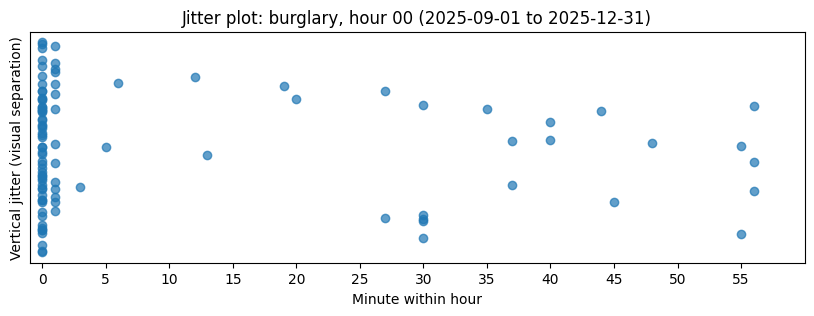

In [10]:
hour_df = sub[sub["hour"] == hour].copy()  # ensure consistent after hour choice
hour_df["jitter"] = np.random.uniform(-0.4, 0.4, size=len(hour_df))

plt.figure(figsize=(10, 3))
plt.scatter(hour_df["minute"], hour_df["jitter"], alpha=0.7)
plt.xlim(-1, 60)
plt.xticks(range(0, 60, 5))
plt.yticks([])
plt.xlabel("Minute within hour")
plt.ylabel("Vertical jitter (visual separation)")
plt.title(f"Jitter plot: {crime}, hour {hour:02d} ({start} to {end})")
plt.show()

The y-axis represents artificial vertical jitter added only for visualization purposes. 
It does not encode any quantitative information but helps prevent overplotting of 
incidents recorded at identical minutes.

In [11]:
minute_counts = hour_df["minute"].value_counts().sort_values(ascending=False)
zero_share = hour_df["minute"].eq(0).mean()
uniform_expectation = 1 / 60

print("Top 10 recorded minutes:\n", minute_counts.head(10))
print(f"\nShare at minute 0: {zero_share:.4f}")
print(f"Uniform expectation (1/60): {uniform_expectation:.4f}")
print(f"Ratio (observed/expected): {zero_share / uniform_expectation:.1f}x")

Top 10 recorded minutes:
 minute
0     55
1     14
30     5
56     3
37     2
55     2
27     2
40     2
48     1
6      1
Name: count, dtype: int64

Share at minute 0: 0.5729
Uniform expectation (1/60): 0.0167
Ratio (observed/expected): 34.4x


What does the plot reveal about recording precision?
The jitter plot reveals strong clustering of incident times at minute 0.
Quantitatively, 57.29% of incidents within the selected hour were recorded at exactly minute 0.
Under a uniform minute-level recording process, only 1 out of 60 minutes (≈1.67%) would be expected to fall on any given minute.
Because the observed proportion is 34.4x larger than the uniform expectation, this indicates a single dominant rounding behavior:
incident times are systematically recorded as HH:00, suggesting officers round to the nearest hour rather than logging the exact minute.
Therefore, the dataset has limited minute-level temporal accuracy, and analyses relying on exact minute timing may be biased.
Hour-level temporal analysis is more reliable than minute-level inference.

### 1.3B

>
> **Part B — Probability plot**
> * Using the same geographic data from Part B, create a probability plot (QQ plot) for the latitude distribution of each of your two crime types. (`scipy.stats.probplot` is your friend here.)
> * What reference distribution are you comparing against? What would it mean if the points fell exactly on the straight line? Where does the distribution deviate from normal, and what does that deviation tell you about the geography of crime in SF?
>

In [12]:
crime_a = "larceny theft"
crime_b = "assault"     
mask_a = df["Incident Category"].str.strip().str.lower().eq(crime_a)
mask_b = df["Incident Category"].str.strip().str.lower().eq(crime_b)

lat_a = df.loc[mask_a, "Latitude"].dropna()
lat_a = lat_a[lat_a < 90] # filter out invalid latitudes 

lat_b = df.loc[mask_b, "Latitude"].dropna()
lat_b = lat_b[lat_b < 90] # filter out invalid latitudes

len(lat_a), len(lat_b), (lat_a.min(), lat_a.max()), (lat_b.min(), lat_b.max())

(712400,
 207644,
 (np.float64(37.70784759521), np.float64(37.82999038696)),
 (np.float64(37.70787902241), np.float64(37.82999038696)))

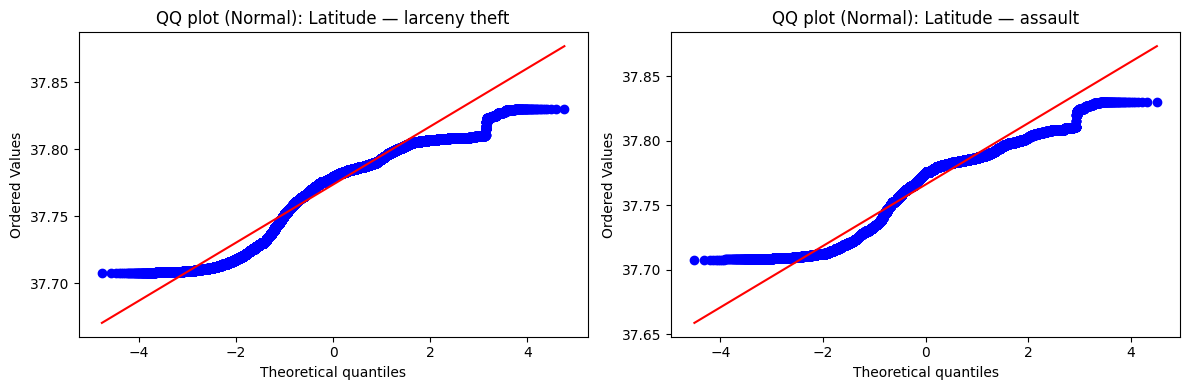

In [13]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

stats.probplot(lat_a, dist="norm", plot=axes[0])
axes[0].set_title(f"QQ plot (Normal): Latitude — {crime_a}")

stats.probplot(lat_b, dist="norm", plot=axes[1])
axes[1].set_title(f"QQ plot (Normal): Latitude — {crime_b}")

plt.tight_layout()
plt.show()

The QQ plot compares the empirical latitude distribution of each crime type against a theoretical normal distribution. The red line represents what the data would look like if it were perfectly normal.

If the points fell exactly on that line, it would mean crime incidents are symmetrically distributed around a central latitude with no geographic clustering — crimes would be equally likely to occur at any distance north or south of the city center.

Both larceny theft and assault deviate from normality in the same way. At the lower tail (quantiles below −2), the points flatten out horizontally at around 37.706, meaning a large number of incidents pile up at that specific southern latitude. The same happens at the upper tail near 37.83. These flat steps are most likely data quality artifacts — rounded or default coordinates assigned when the exact location was unknown, consistent with the coordinate precision issue observed in the temporal analysis.

In the middle section, a slight S-curve indicates heavier tails than a normal distribution, meaning crime concentrates in specific areas rather than spreading symmetrically across the city.

The most geographically interesting finding is that both crime types produce nearly identical QQ plot shapes, suggesting larceny theft and assault share the same high-density neighborhoods. Crime type alone does not strongly differentiate where incidents occur in San Francisco.

### 1.3C
> **Part C — Box plots of time-of-day**
> * For each of your Personal Focus Crimes, extract the time-of-day of every incident.
> * Create box plots showing the time-of-day distribution for all your Personal Focus Crimes side by side.
> * What patterns do you see? Are there crimes that happen mostly at night? Mostly during business hours? For crimes that peak late at night, does the box plot handle the wrap-around at midnight well? What goes wrong?
> * Above, feel free to use alternatives to box plots — violin plots, swarm plots, or raincloud plots — if you think they reveal more. If you do, briefly explain what the alternative shows that the box plot doesn't.

In [14]:
# Filter df to only the 10 focus crimes
focus_crimes = ["assault", "larceny theft", "motor vehicle theft", "burglary", 
                "robbery", "gambling", "sex offense", "weapons offense", "fraud", "arson"]

c = df.copy()
c["Incident Category"] = c["Incident Category"].str.strip().str.lower()
c = c[c["Incident Category"].isin([x.lower() for x in focus_crimes])].copy()

# Ensure date and time columns are proper datetime objects (not strings)
c["Incident Date"] = pd.to_datetime(c["Incident Date"], errors="coerce")
c["Incident Time"] = pd.to_datetime(c["Incident Time"], errors="coerce")

# Combine date + time into a single timestamp per incident
# (they are stored in separate columns so we need to merge them)
c["Incident Datetime"] = c["Incident Date"] + (
    pd.to_timedelta(c["Incident Time"].dt.hour, unit="h") +
    pd.to_timedelta(c["Incident Time"].dt.minute, unit="m")
)

# Extract time-of-day as minutes since midnight (0 = midnight, 1439 = 23:59)
# This is what we plot to compare crime timing across types
c["tod_min"] = c["Incident Datetime"].dt.hour * 60 + c["Incident Datetime"].dt.minute

# Sanity check
c[["Incident Category", "Incident Datetime", "tod_min"]].head()

,Incident Category,Incident Datetime,tod_min
1,assault,2025-08-27 00:37:00,37
2,fraud,2025-07-17 15:00:00,900
3,larceny theft,2025-08-23 21:30:00,1290
5,motor vehicle theft,2025-08-15 21:45:00,1305
6,larceny theft,2025-08-14 21:00:00,1260


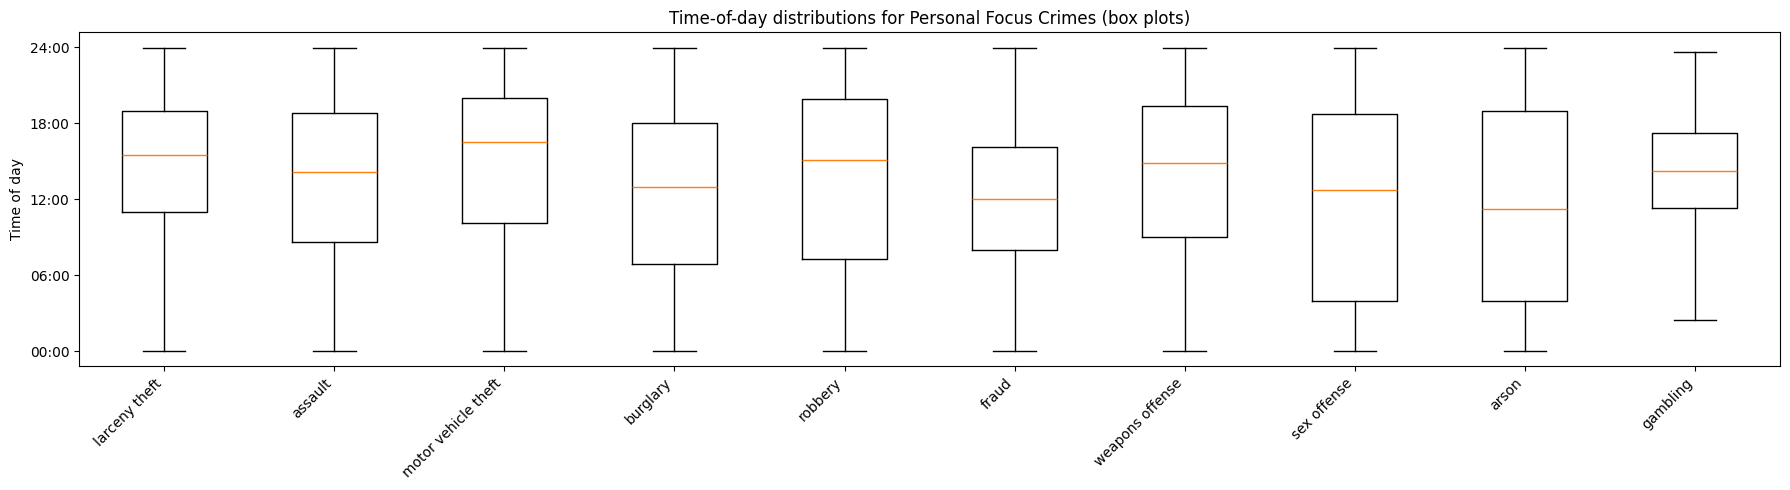

In [15]:
# Minutes since midnight for time-of-day representation
c["tod_min"] = c["Incident Datetime"].dt.hour * 60 + c["Incident Datetime"].dt.minute

focus_crimes = ["larceny theft", "assault", "motor vehicle theft", "burglary",
                "robbery", "fraud", "weapons offense", "sex offense", "arson", "gambling"]

# Extract tod_min per crime type in the same order as focus_crimes
data = [c.loc[c["Incident Category"] == crime, "tod_min"].dropna() for crime in focus_crimes]

plt.figure(figsize=(18, 5))
plt.boxplot(data, tick_labels=focus_crimes, showfliers=False)
plt.xticks(rotation=45, ha="right")

# Y-axis in human-readable time instead of raw minutes
plt.yticks([0, 360, 720, 1080, 1440], ["00:00", "06:00", "12:00", "18:00", "24:00"])
plt.ylabel("Time of day")
plt.title("Time-of-day distributions for Personal Focus Crimes (box plots)")
plt.tight_layout()
plt.show()

Most crime types show a broad daytime distribution with medians falling between noon and 16:00, suggesting that afternoon hours are the most active period across the board. The interquartile ranges are wide for nearly all categories, meaning no single crime type is tightly locked to a specific time window — incidents are spread throughout the day.

Gambling is the clearest exception, showing a noticeably tighter box that indicates more predictable timing. Fraud skews slightly earlier, consistent with business-hours activity, while burglary and sex offense show similar afternoon concentration.

The main limitation of box plots here is the midnight wrap-around problem. Since time-of-day is represented as minutes from 0 to 1440, a crime at 23:30 and one at 00:30 appear at opposite ends of the scale despite being only one hour apart. This causes crimes that peak late at night to appear artificially spread across the full range, making the box plot misleading for those categories.

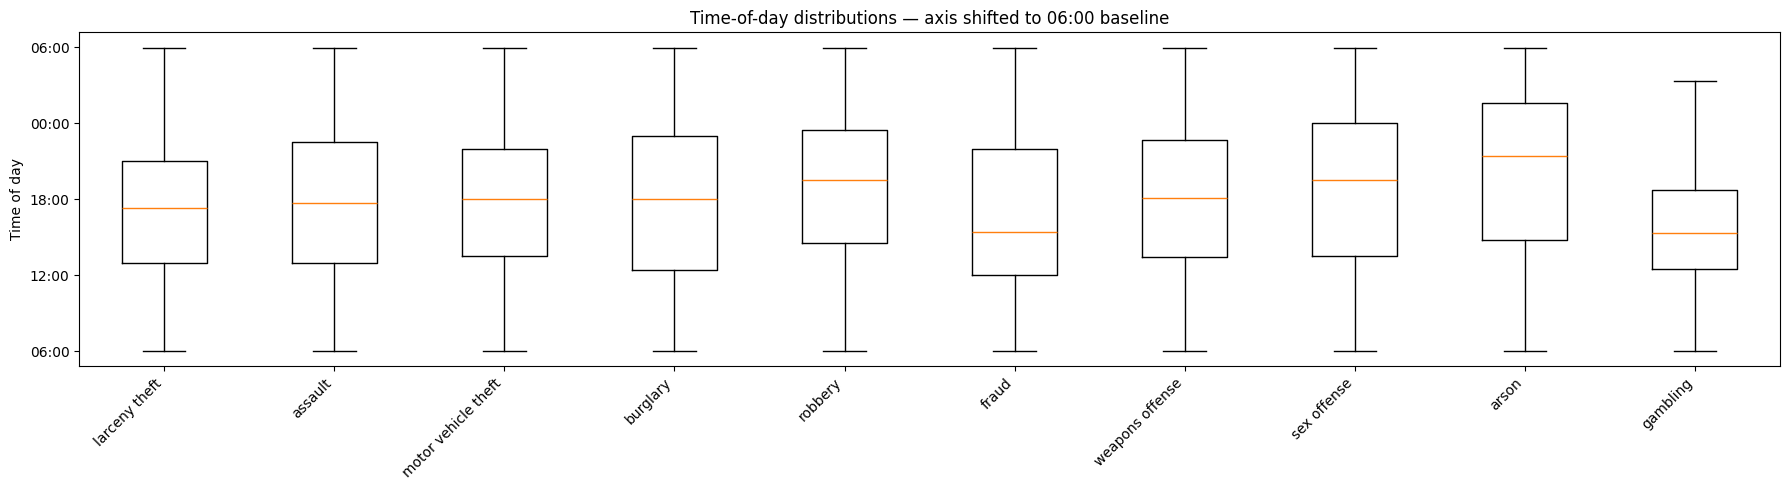

In [16]:
# Shift time so 06:00 becomes the new "zero"
# Wrap-around now happens at the quietest point of the day instead of midnight
c["tod_min_shifted"] = (c["tod_min"] - 360) % 1440

data_shifted = [c.loc[c["Incident Category"] == crime, "tod_min_shifted"].dropna() 
                for crime in focus_crimes]

plt.figure(figsize=(18, 5))
plt.boxplot(data_shifted, tick_labels=focus_crimes, showfliers=False)
plt.xticks(rotation=45, ha="right")

# Relabel y-axis to show real clock times (shifted by 6 hours)
plt.yticks(
    [0, 360, 720, 1080, 1440],
    ["06:00", "12:00", "18:00", "00:00", "06:00"]
)
plt.ylabel("Time of day")
plt.title("Time-of-day distributions — axis shifted to 06:00 baseline")
plt.tight_layout()
plt.show()

Handling the Midnight Wrap-Around
The initial box plot used raw minutes since midnight (0–1440) as the time-of-day axis. This causes a structural problem: crimes that peak late at night get split across the two ends of the scale, making their distribution appear artificially wide. A crime at 23:30 and one at 00:30 are one hour apart in reality but appear at opposite ends of the plot.

To fix this, we shifted the time axis by 6 hours, making 06:00 the new baseline. This choice is deliberate — 06:00 is the quietest period of the day for most crime types, so placing the wrap-around there minimizes distortion. The transformation is simply (tod_min - 360) % 1440, which preserves all the data while rotating the scale.

With the corrected axis, the picture becomes clearer. Most crime types concentrate in the afternoon-to-late-evening window, with medians sitting between 18:00 and 00:00. Gambling continues to stand out with the tightest interquartile range, suggesting it follows a more predictable schedule than other crime types. Fraud skews earlier, consistent with daytime activity. No crime type wraps around the early morning cutoff, confirming the shift resolved the original problem.

---
## Assignment 1.4: Spatial Power Law

Is crime spread evenly across San Francisco, or is it concentrated in a small number of hotspots? Let's find out.

*Draws from*: Week 4, Exercise 2.2.

Use your **most common Personal Focus Crime** (by total incident count) for this exercise.

> * **Step 1**: Divide San Francisco into a grid of approximately $100\text{m} \times 100\text{m}$ cells using latitude and longitude. It is fine to ignore that the Earth isn't flat — the approximation is good enough for this purpose.
>     * **Hint**: `np.histogram2d` works well here. Focus on points within the SF peninsula; filter out geographic outliers.
> * **Step 2**: Count the number of incidents of your chosen crime in each grid cell (use all years of data).
> * **Step 3**: Tally the distribution. Count how many cells have exactly $k$ incidents — call this $N(k)$ — for $k = 0, 1, 2, \ldots$ up to the maximum.
> * **Step 4**: Plot $(k+1)$ vs $N(k)$ on **linear axes**.
> * **Step 5**: Plot $(k+1)$ vs $N(k)$ on **loglog axes**.
> * **Step 6**: Does your crime follow a power-law spatial distribution? How can you tell from the loglog plot?
> * **Step 7**: If crime is spatially concentrated in a small number of cells, what does that imply for how we interpret neighborhood-level crime statistics? Does the "average block" tell you anything useful?

My most common focus crime is: larceny theft


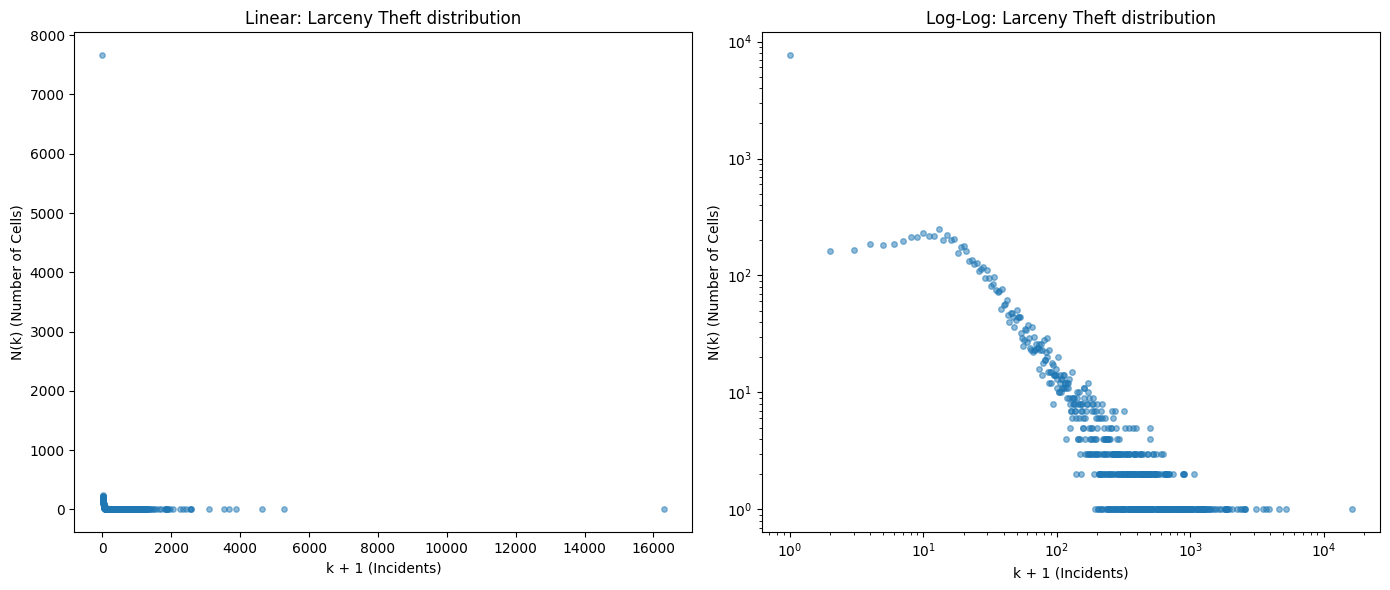

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data first
df = pd.read_csv('SFPD_Combined_Data.csv')

# Standardize names and filter for my 10 focus crimes
my_focus = ["assault", "larceny theft", "motor vehicle theft", "burglary", 
            "robbery", "gambling", "sex offense", "weapons offense", "fraud", "arson"]

df['Incident Category'] = df['Incident Category'].str.lower()
df_filtered = df[df['Incident Category'].isin(my_focus)].copy()

# Find the most common crime
top_crime = df_filtered['Incident Category'].value_counts().idxmax()
print(f"My most common focus crime is: {top_crime}")

# Filter for the SF peninsula to remove geographic outliers
# Rough SF bounds: Lat (37.70 to 37.82), Lon (-122.52 to -122.35)
sf_data = df_filtered[
    (df_filtered['Incident Category'] == top_crime) &
    (df_filtered['Latitude'].between(37.70, 37.82)) &
    (df_filtered['Longitude'].between(-122.52, -122.35))
].copy()

# Step 1 & 2: Grid and Counting
# 100m is roughly 0.001 degrees in lat/lon
lon_bins = np.arange(sf_data['Longitude'].min(), sf_data['Longitude'].max(), 0.001)
lat_bins = np.arange(sf_data['Latitude'].min(), sf_data['Latitude'].max(), 0.001)

counts, _, _ = np.histogram2d(sf_data['Longitude'], sf_data['Latitude'], bins=[lon_bins, lat_bins])

# Step 3: Tally the counts N(k)
flat_counts = counts.flatten()
k_values, N_k = np.unique(flat_counts, return_counts=True)

# Step 4 & 5: Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Linear Plot
ax1.scatter(k_values + 1, N_k, alpha=0.5, s=15)
ax1.set_title(f'Linear: {top_crime.title()} distribution')
ax1.set_xlabel('k + 1 (Incidents)')
ax1.set_ylabel('N(k) (Number of Cells)')

# Log-Log Plot
ax2.loglog(k_values + 1, N_k, 'o', alpha=0.5, markersize=4)
ax2.set_title(f'Log-Log: {top_crime.title()} distribution')
ax2.set_xlabel('k + 1 (Incidents)')
ax2.set_ylabel('N(k) (Number of Cells)')

plt.tight_layout()
plt.show()

Largency theft does follow a power-law. This can be seen from the log-log plot, there is a downward slope from 10^1 to 10^2. The first part of the log-log plot (from 10^0 to 10^1) is noise, because there are thousands of grid cells which only have a tiny number of crimes across the 20-year period. Then from 10^1 to 10^2 there is a downward slope which shows the power law in action. After about 10^2, there are several horizontal lines, these represent that only a few cells have that much incidents. So the first and last section are just outliers, and ignoring those there is a clear straight downward sloping line, representing a power law.

Neighborhood-level statistics can be quite misleading because a few extreme hotspots heavily skew the data. This means the "average block" is essentially a useless metric, as it doesn't represent the safe reality of most streets in a given area. Since the analysis shows that crime is so heavily concentrated, it suggests that the government should focus on fixing specific street corners rather than entire districts. In reality, most blocks within a "high-crime" neighborhood are actually pretty safe; the danger is restricted to specific 100m corners rather than the whole area.

---
## Assignment 1.5: Regression and Correlation

Which of your Personal Focus Crimes share the most similar weekly rhythm — and which are completely out of sync?

*Draws from*: Week 4, Exercises 3.1, 3.2, and 3.3.

Select **at least 4** of your Personal Focus Crimes for this exercise. More is fine - if you want to be closer to the actual weekly exercise.

> * For each selected crime type, compute the total number of incidents for each of the **168 hours of the week** (i.e., Monday 00:00–01:00, Monday 01:00–02:00, ..., Sunday 23:00–00:00). Each crime type will give you a vector of 168 values.
>
> * **Scatterplot matrix**: Create a grid of pairwise scatterplots — one panel per pair of crime types, with one crime on each axis and each of the 168 hours as a point. Label each panel clearly with the two crime types being compared.
>
> * **Linear regression**: Using the closed-form equations from Week 4 (not a library), fit a regression line $y = ax + b$ to each pair and add it to the relevant panel:
>   $$a = \frac{\sum_i x_i y_i - N\langle x\rangle\langle y\rangle}{\sum_i x_i^2 - N\langle x\rangle^2}, \qquad b = \langle y \rangle - a\langle x \rangle$$
>
> * **$R^2$**: Compute $R^2$ for each pair and display the value on each panel. 
>
> * Looking at your results: which pair of crimes is **most correlated**? Which is **least correlated**? Does the answer match your intuition? Why might two crime types share a weekly rhythm — or not?

/var/folders/vf/5fp3km_j7cgbcrs85nqynb000000gn/T/ipykernel_59437/403040035.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_focus['Hour'] = pd.to_datetime(df_focus['Incident Time'], errors='coerce').dt.hour


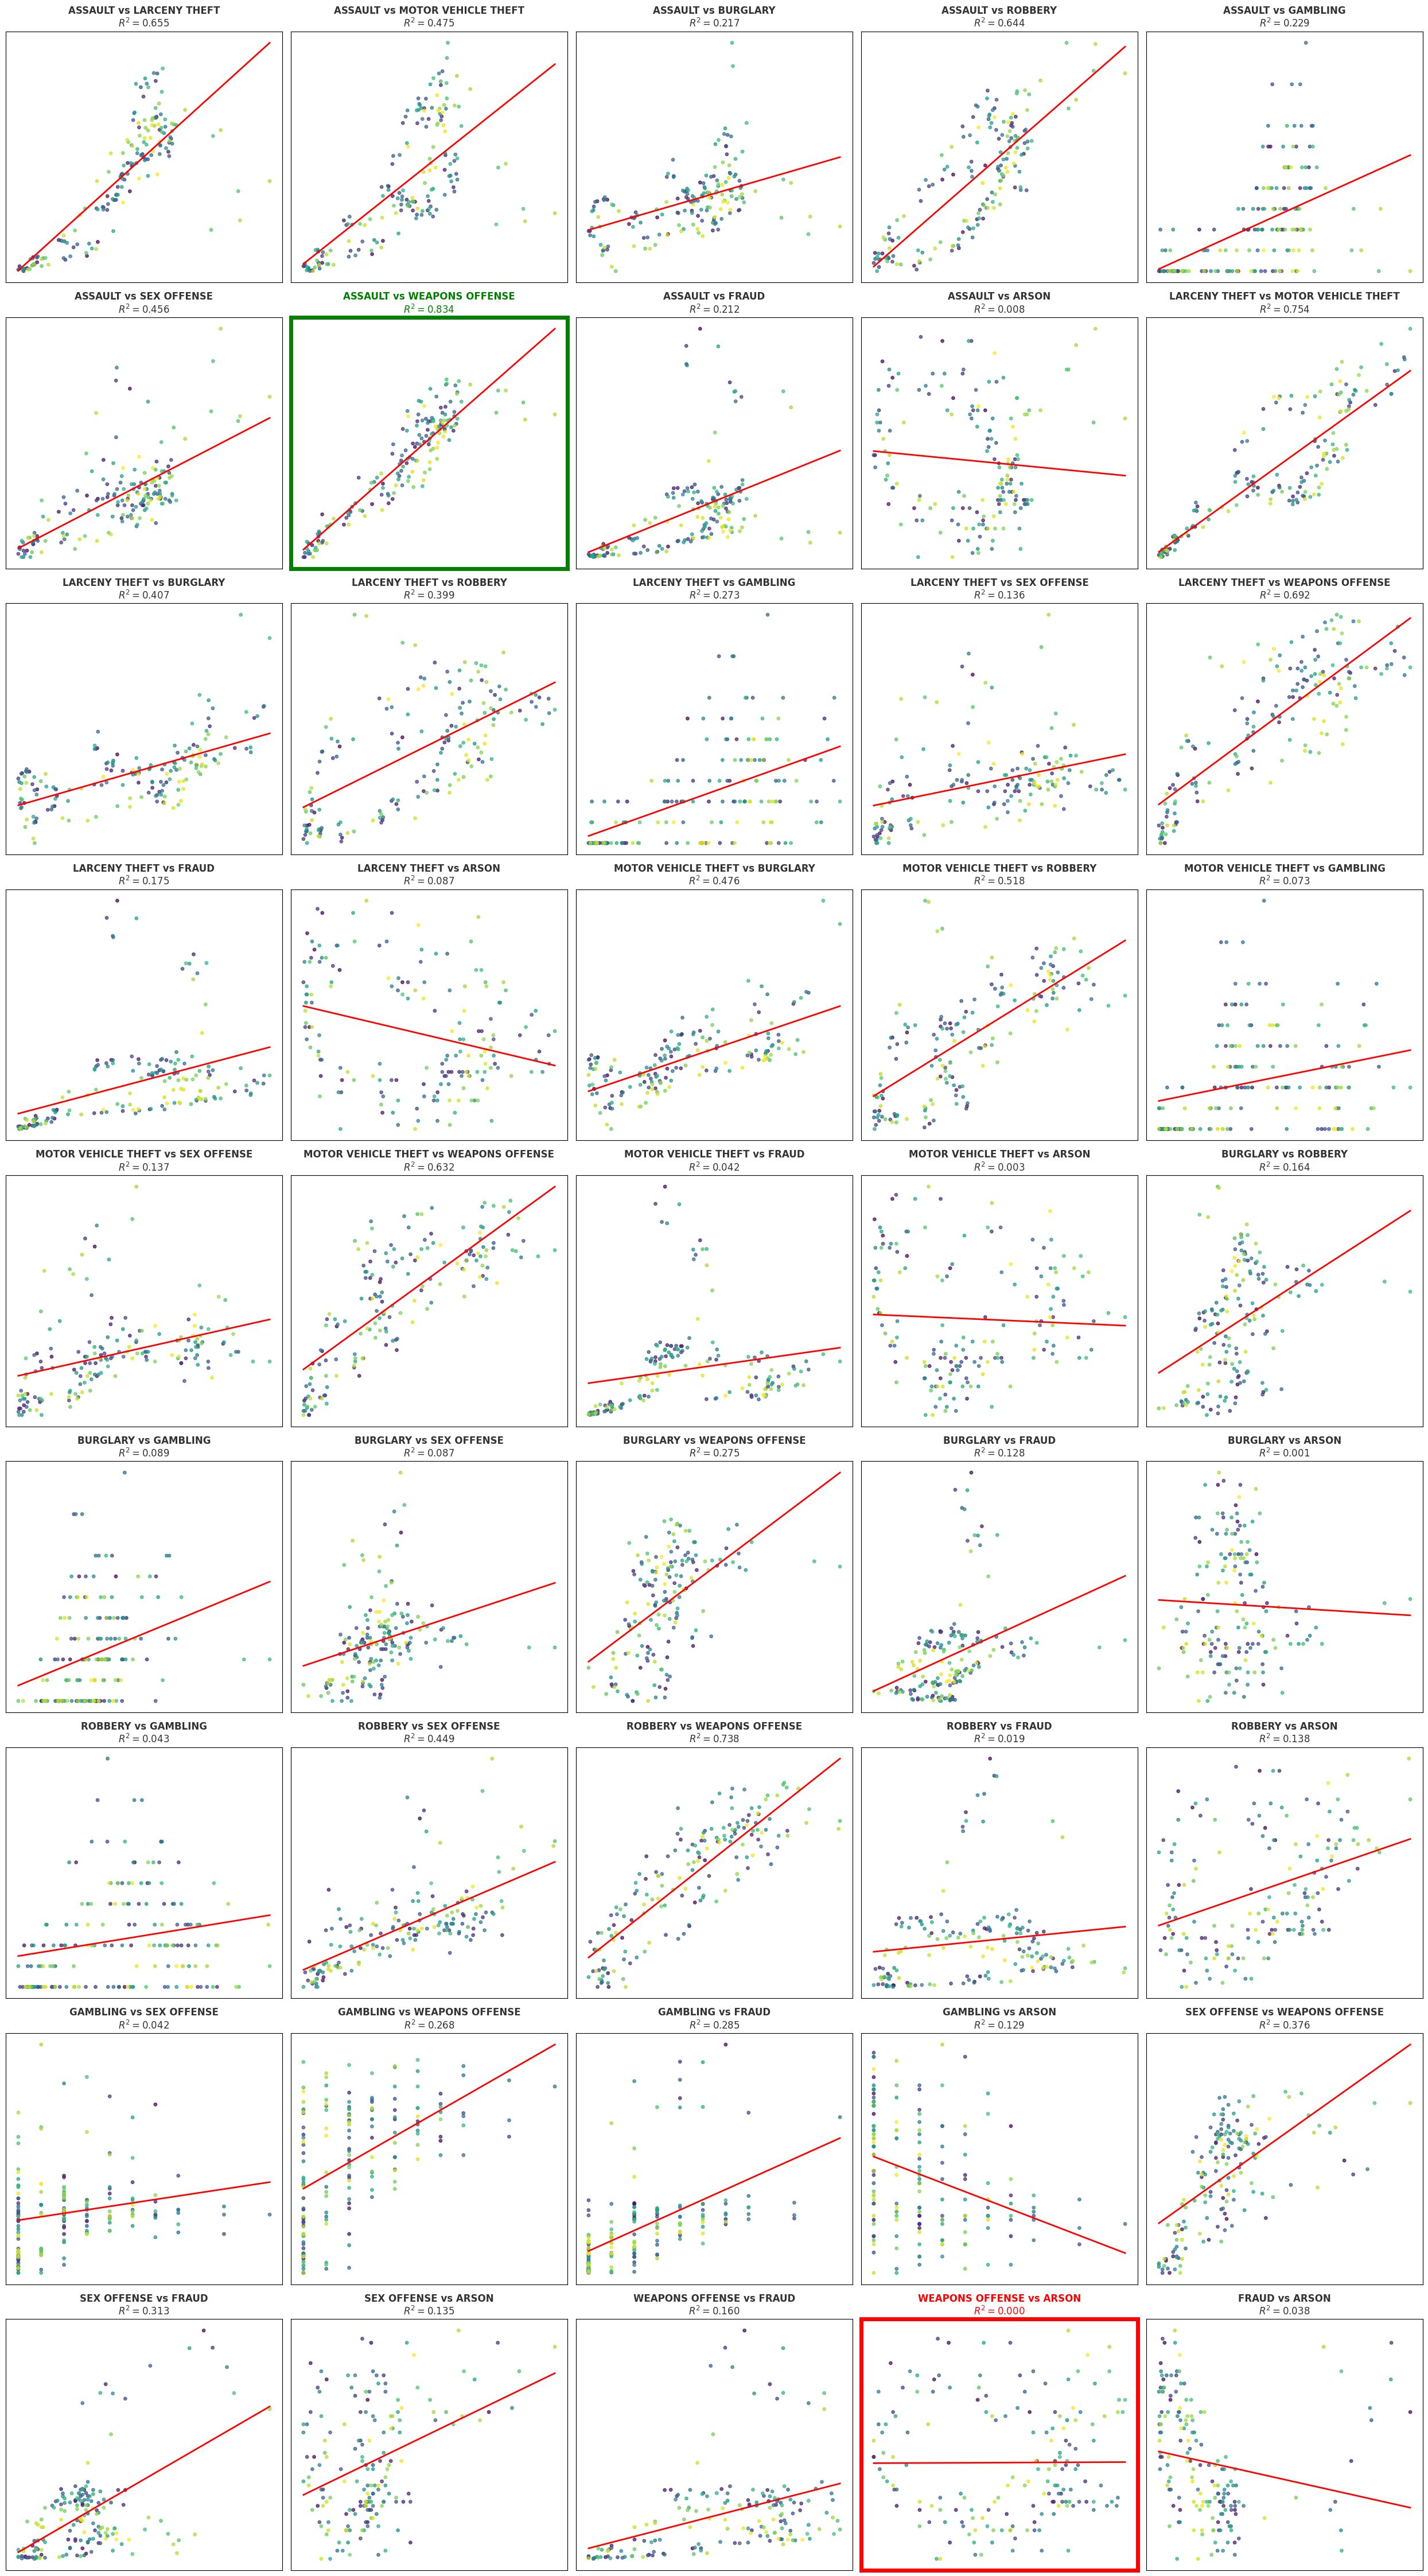

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

# 1. Load Data
df = pd.read_csv('SFPD_Combined_Data.csv')

# 2. Define my 10 Personal Focus Crimes
my_focus = ["assault", "larceny theft", "motor vehicle theft", "burglary", 
            "robbery", "gambling", "sex offense", "weapons offense", "fraud", "arson"]

df['Incident Category'] = df['Incident Category'].str.lower()
df_focus = df[df['Incident Category'].isin(my_focus)].copy()

# 3. Compute 168-hour vectors
df_focus['Incident Date'] = pd.to_datetime(df_focus['Incident Date'])
df_focus['Hour'] = pd.to_datetime(df_focus['Incident Time'], errors='coerce').dt.hour
df_focus['HourOfWeek'] = df_focus['Incident Date'].dt.dayofweek * 24 + df_focus['Hour']

pivot_df = df_focus.groupby(['HourOfWeek', 'Incident Category']).size().unstack(fill_value=0)

# 4. Calculation and Ranking
crime_pairs = list(combinations(my_focus, 2))
results = []

for c1, c2 in crime_pairs:
    x = pivot_df[c1].values.astype(float)
    y = pivot_df[c2].values.astype(float)
    N = len(x)
    
    # Manual Regression
    x_mean, y_mean = np.mean(x), np.mean(y)
    num = np.sum(x * y) - N * x_mean * y_mean
    den = np.sum(x**2) - N * (x_mean**2)
    
    a = num / den if den != 0 else 0
    b = y_mean - a * x_mean
    
    # R^2
    y_pred = a * x + b
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - y_mean)**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    
    results.append({'pair': (c1, c2), 'x': x, 'y': y, 'a': a, 'b': b, 'r2': r2})

# Identify extreme pairs
most_corr = max(results, key=lambda x: x['r2'])
least_corr = min(results, key=lambda x: x['r2'])

# 5. Plotting (9 rows x 5 columns for 45 pairs)
fig, axes = plt.subplots(9, 5, figsize=(25, 45), facecolor='white')
axes = axes.flatten()
colors = plt.cm.viridis(np.linspace(0, 1, 168))

for i, res in enumerate(results):
    ax = axes[i]
    c1, c2 = res['pair']
    
    # Scatter points colored by hour
    ax.scatter(res['x'], res['y'], c=colors, s=15, alpha=0.7)
    
    # Manual fit line
    x_range = np.array([res['x'].min(), res['x'].max()])
    ax.plot(x_range, res['a'] * x_range + res['b'], color='red', lw=2)
    
    # Highlighting logic
    title_color = '#333333'
    if res['pair'] == most_corr['pair']:
        title_color = 'green'
        for spine in ax.spines.values(): 
            spine.set_edgecolor('green'); spine.set_linewidth(5)
    elif res['pair'] == least_corr['pair']:
        title_color = 'red'
        for spine in ax.spines.values(): 
            spine.set_edgecolor('red'); spine.set_linewidth(5)
            
    ax.set_title(f"{c1.upper()} vs {c2.upper()}\n$R^2 = {res['r2']:.3f}$", 
                 color=title_color, fontsize=12, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])


plt.tight_layout()
plt.show()

The most correlated pair of crimes that was found is assault vs weapons offense with an r^2 of 0.834. The least correlated pair is weapons offense vs arson with an r^2 of 0.000 (rounded, it was actually 0.000028).

For the most correlated pair ,assault vs weapons offense, this result matches my intuition because these two crimes are linked. When people are fighting ,there is a much high chance that a weapon is involved. They happen for the same reasons and at the exact same times, like during late night social gatherings where tensions run high and people have done drugs or alcohol.

The least correlated pair ,weapons offense vs arson, also matches my intuition. This is because Arson is often a crime that only happens when nobody is around to see it. While weapons offenses happen where there are big crowds and lots of police, arson might actually be higher when streets are empty and quiet. Even though both crimes peak on weekends, they happen at different times for opposite reasons. This is why it shows almost no correlation between them.

Two crime types share a weekly rhythm when they are driven by the same external factors. For example, crimes that target people often peak during busy hours or weekend nights because that is when the most targets are available. Crimes stay out of sync when they have different triggers. A crime like fraud usually follows a daytime business schedule, while street crimes like robbery happen late at night. 

### References

San Francisco Department of Public Health. (2020). Public Health Order C19-07 (Shelter-in-Place), effective March 17, 2020. https://www.sfhsa.org/about/announcements/new-public-health-order-requiring-residents-stay-home-except-essential-needs

Google. (2020). COVID-19 Community Mobility Reports. https://www.google.com/covid19/mobility/

Ashby, M. P. J. (2020). Initial evidence on the relationship between the coronavirus pandemic and crime in the United States. Crime Science, 9(6). https://pubmed.ncbi.nlm.nih.gov/32455094/

San Francisco Planning Department. (2017). San Francisco Neighborhood Socio-Economic Profiles (ACS 2010-2014). https://default.sfplanning.org/publications_reports/SF_NGBD_SocioEconomic_Profiles/2010-2014_ACS_Profile_Neighborhoods_v3AH.pdf

San Francisco Mayor's Office of Housing and Community Development (MOHCD). (2021). 2020-2024 Consolidated Plan and 2020-2021 Action Plan. https://sfmohcd.org/sites/default/files/Documents/Reports/Feb%202021%20Full%20Amended%202020-2024%20Consolidated%20Plan%20and%202020-2021%20Action%20Plan-compressed_0.pdf

### LLM Usage Disclosure

This notebook used an LLM only for coding assistance, pandas syntax support, and plot formatting, in line with the course guidance stated in the exercise instructions.
No LLM support was used for interpretation, reflection, or argumentative conclusions.


### Group Contribution Matrix

| Member  | Exercise 1 | Exercise 2 | Exercise 3 | Exercise 4 | Exercise 5 |
|---------|------------|------------|------------|------------|------------|
| s253129 |     Χ      |    Χ       |            |            |            |
| s253154 |            |            |     Χ      |            |            |
| s257688 |            |            |            |     Χ      |     Χ      |
